## Loading data

In [8]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
pd.set_option("display.max_columns", None)

if os.getenv("KAGGLE_KERNEL_RUN_TYPE"):
    ENV = "kaggle"
    DATA_DIR = Path("/kaggle/input/competitions/playground-series-s6e3")
    ORIG_DIR = Path("/kaggle/input/datasets/cdeotte/s6e3-original-dataset")
else:
    ENV = "local"
    DATA_DIR = Path("./data/")
    ORIG_DIR = DATA_DIR
print(f"Environment: {ENV}")
train = pd.read_csv(DATA_DIR/"train.csv").drop("id", axis=1)
test = pd.read_csv(DATA_DIR/"test.csv").drop("id", axis=1)
orig_fn = "original.csv" if ENV == "local" else "WA_Fn-UseC_-Telco-Customer-Churn.csv"
original = pd.read_csv(DATA_DIR/orig_fn).drop("customerID", axis=1)
sub = pd.read_csv(DATA_DIR/"sample_submission.csv")
print("Data Loaded")

Environment: local
Data Loaded


In [12]:
display(f"Train shape: {train.shape}")
display(train.head(3))
display(f"Test shape: {test.shape}")
display(test.head(3))
display(f"Original shape: {original.shape}")
display(original.head(3))

'Train shape: (594194, 20)'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


'Test shape: (254655, 19)'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


'Original shape: (7043, 20)'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Preprocessing steps

- Encode the target variable `Churn`
- Convert `SeniorCitizen` to object type to work with scikit-learn pipeline and exploratory vizualization
- Convert `TotalCharges` in the original dataset to a number.
- Fix `TotalCharges` empty string with zeros (rows with `tenure == 0`)

In [14]:
for df in (train, original):
    df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [15]:
for df in (train, test, original):
    df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [18]:
original["TotalCharges"] = pd.to_numeric(original["TotalCharges"], errors="coerce")
original.loc[original["tenure"]==0, "TotalCharges"] = 0

### Constant variables

In [33]:
TARGET = "Churn"
FEATS = test.columns.tolist()
CATS = test.select_dtypes(include="object").columns.tolist()
NUMS = test.select_dtypes(include="number").columns.tolist()
DSEED = 10431053

## Target - Churn

The minority class ratio is around 29%. Mild imbalance; most models will handle it without many problems.

What's more interesting is the ~4pp distribution shift between train and original datasets, probably from the synthetic generation. If we extract target-encoded features from the original dataset, the slightly different base rate suggests using smoothed/regularized encodings. Otherwise, we will be injecting a biased prior, telling the model a rate that's systematically too high because it was computed under a different class distribution. 

In [32]:
mcr = train.Churn.mean()/ (1- train.Churn.mean()) * 100
print(f"Minority class ratio: {mcr:.2f}%")

Minority class ratio: 29.07%


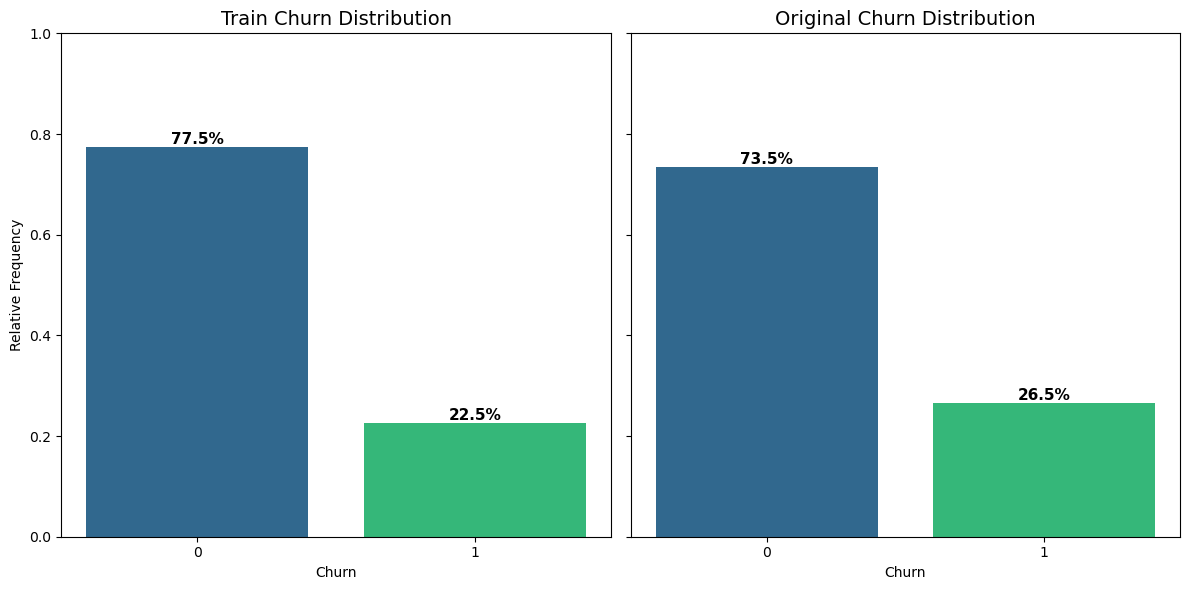

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, (name, df) in zip(axes, [("Train", train), ("Original", original)]):
    counts = df[TARGET].value_counts(normalize=True).sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("viridis", 2))
    ax.set_title(f"{name} Churn Distribution", fontsize=14)
    ax.set_ylabel("Relative Frequency" if ax == axes[0] else "")
    ax.set_xlabel("Churn")
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, counts.values):
        ax.annotate(f'{val:.1%}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Features Analysis

The dataset comprises 19 features, of which 16 are categorical with 2 to 4 categories each, and 3 are numerical 

Base Features (19): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Numerical features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


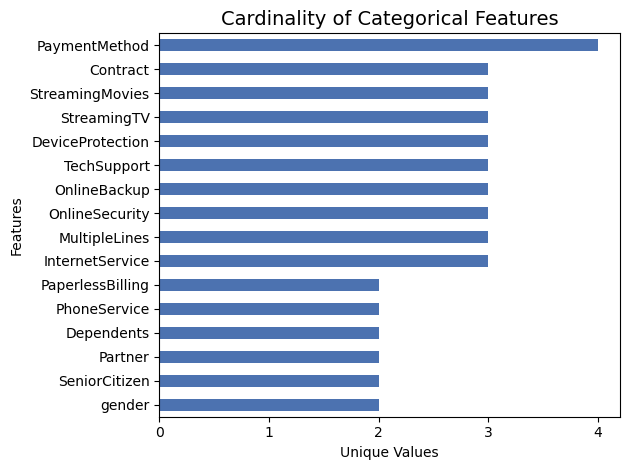

In [66]:
print(f"Base Features ({len(FEATS)}): {FEATS}\n")
print(f"Numerical features ({len(NUMS)}): {NUMS}")
print(f"Categorical Features ({len(CATS)}): {CATS}")
ax = train[CATS].nunique().sort_values().plot.barh(color="#4C72B0")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("Cardinality of Categorical Features", fontsize=14)
ax.set_xlabel("Unique Values")
ax.set_ylabel("Features")
plt.tight_layout()

### Distribution analysis

Tenure shows a bimodal distribution with peaks at both extremes. Train/Test are aligned, but the train set has a sharper peak than the original. The synthetic process could amplify "loyal customers" (high tenure).

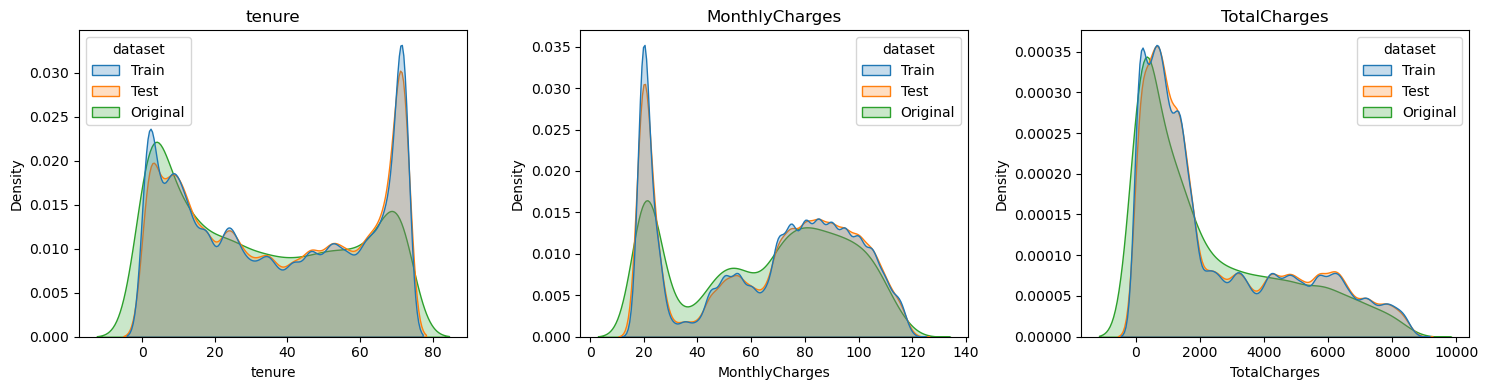

In [69]:
df_all = pd.concat([
    train[NUMS].assign(dataset='Train'),
    test[NUMS].assign(dataset='Test'),
    original[NUMS].assign(dataset='Original')
])

n_cols = 3
n_rows = (len(NUMS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMS):
    sns.kdeplot(data=df_all, x=col, hue='dataset', ax=axes[i], 
                fill=True, common_norm=False, warn_singular=False)
    axes[i].set_title(col)

for i in range(len(NUMS), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()
del df_all

Tenure shows a negative relationship and is a very smooth pattern. Consider a log-transformation to capture the early drop or the inverse transformation (1/x) for linear models.

MonthlyCharges shows a more erratic pattern than tenure. This is a feature where raw values won't capture the signal well. It's a prime candidate for interaction with tenure.

TotalCharges is likely to be confounded with tenure since TotalCharges ≈ tenure x MonthlyCharges. So the negative relationship is probably driven by tenure.

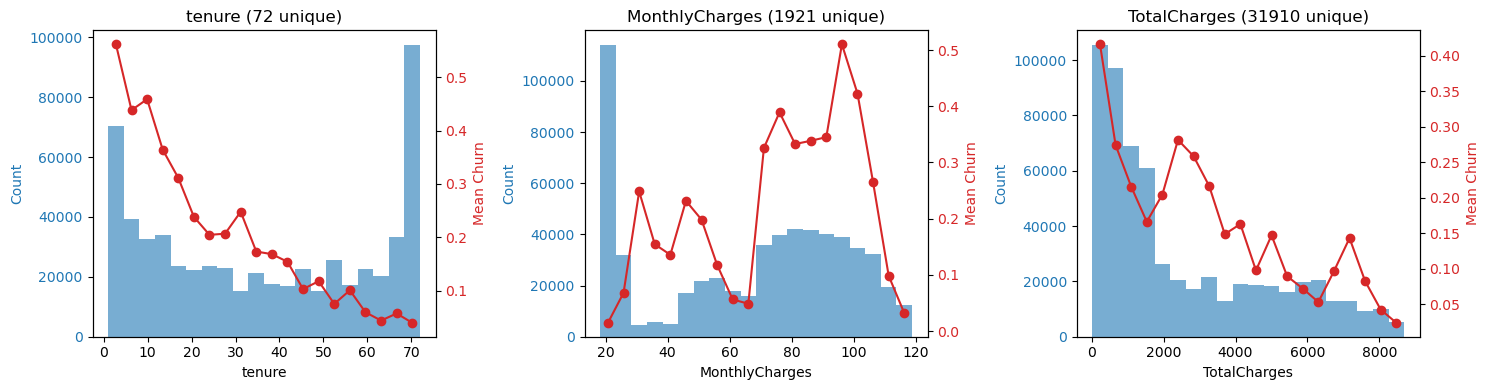

In [89]:
n_cols = 3
n_rows = (len(NUMS) + n_cols - 1) // n_cols
n_bins = 20

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMS):
    ax1 = axes[i]
    x = train[col].dropna().values
    y = train.loc[train[col].notna(), 'Churn'].values

    unique_vals = np.sort(np.unique(x))
    n_unique = len(unique_vals)

    # Low-cardinality: one bar per unique value
    if n_unique <= 20:
        counts = np.array([(x == v).sum() for v in unique_vals])
        mean_y = np.array([y[x == v].mean() for v in unique_vals])
        xpos = np.arange(n_unique)

        ax1.bar(xpos, counts, alpha=0.6, color='tab:blue')
        ax1.set_xticks(xpos)
        ax1.set_xticklabels(unique_vals.astype(int) if np.all(unique_vals == unique_vals.astype(int)) else unique_vals,
                            rotation=45 if n_unique > 10 else 0, 
                            ha='right' if n_unique > 10 else 'center')

        ax2 = ax1.twinx()
        ax2.plot(xpos, mean_y, marker='o', color='tab:red')

    # High-cardinality: binned histogram
    else:
        bins = np.linspace(x.min(), x.max(), n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        counts, _ = np.histogram(x, bins=bins)
        bin_idx = np.digitize(x, bins) - 1
        mean_y = np.array([y[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                           for j in range(n_bins)])

        ax1.bar(bin_centers, counts, width=(bins[1] - bins[0]), alpha=0.6, color='tab:blue')

        ax2 = ax1.twinx()
        ax2.plot(bin_centers, mean_y, marker='o', color='tab:red')

    ax1.set_xlabel(col)
    ax1.set_ylabel('Count', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylabel('Mean Churn', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_title(f'{col} ({n_unique} unique)')

for i in range(len(NUMS), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

To isolate the signal, we compute "Charge Residual":

$$\text{ChargeResidual = TotalCharges - tenure × MonthlyCharges}$$

Interpretation:
- Negative: customers paid less than expected due to discounts or promotions.
- Positive: customers paid more than expected due to upgraded plans, added services, etc.
- Zero: stable customer, never changed.

The median of the "charge residual" is zero, meaning roughly half the customers never changed plans, but the spread is substantial.

As feature engineering ideas, we extract the sign and the relative magnitude of Charge Residual. This decomposition might interact differently with churn. For example, a customer who deviated 10% from the expected could be more meaningful than one who deviate $50 on a $5000 total.

In [113]:
def ChargeRes_transform(df):
    df = df.copy()
    df["ChargeRes"] = df["TotalCharges"] - df["tenure"] * df["MonthlyCharges"]
    df["ChargeRes_abs"] = df["ChargeRes"].abs()
    df["ChargeRes_sign"] = np.sign(df["ChargeRes"]).astype(int)
    df["ChargeRes_pct"] = df["ChargeRes"] / (df["TotalCharges"] + 1)
    return df

In [121]:
train = ChargeRes_transform(train)
test = ChargeRes_transform(test)
original = ChargeRes_transform(original)

Customers who deviate from expected charges in either direction churn more, but the extreme bins have almost no observations, so the reliable signal is in the central range where the blue bars have mass. 

- `ChargeRes_abs` confirms the u-shape but the data is very concentrated at zero.
- `ChargeRes_sign` is useless: -1 / +1 groups have almost identical churn rate.
- `ChargeRes_pct` has nearly all the mass at 0, so the churn rate is not reliable. 

To understand the reliability of the mean, consider an example: a bin has 500k customers. The mean churn is computed over 500k obs, so the estimate is very stable. Even if you resampled, you'd get nearly the same number. Now say a bin has 50 customers. If 30 of them happen to churn you get a mean 60%, but if 5 of those had stayed, you would get 50% instead. The estimate swings widely because for n=50 the standard error is large.

Let $y_i \in {0,1}$ be the churn indicator and $n$ the number of obs in the bin. The sample proportion (mean of a Bernoulli):
$$\hat{p} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

The standard error tells us how much the estimate can vary due to random sampling:
$$\text{SE}(\hat{p}) = \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}$$

For a 95% confidence interval on the bin's true churn rate:
$$\hat{p} \pm 1.96 \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

So in our previous example, a bin with $n=50$ and $\hat{p}=0.6$ has a 95% CI of roughly [0.46,0.74]. You cannot meaningfully distinguish that from 0.5.

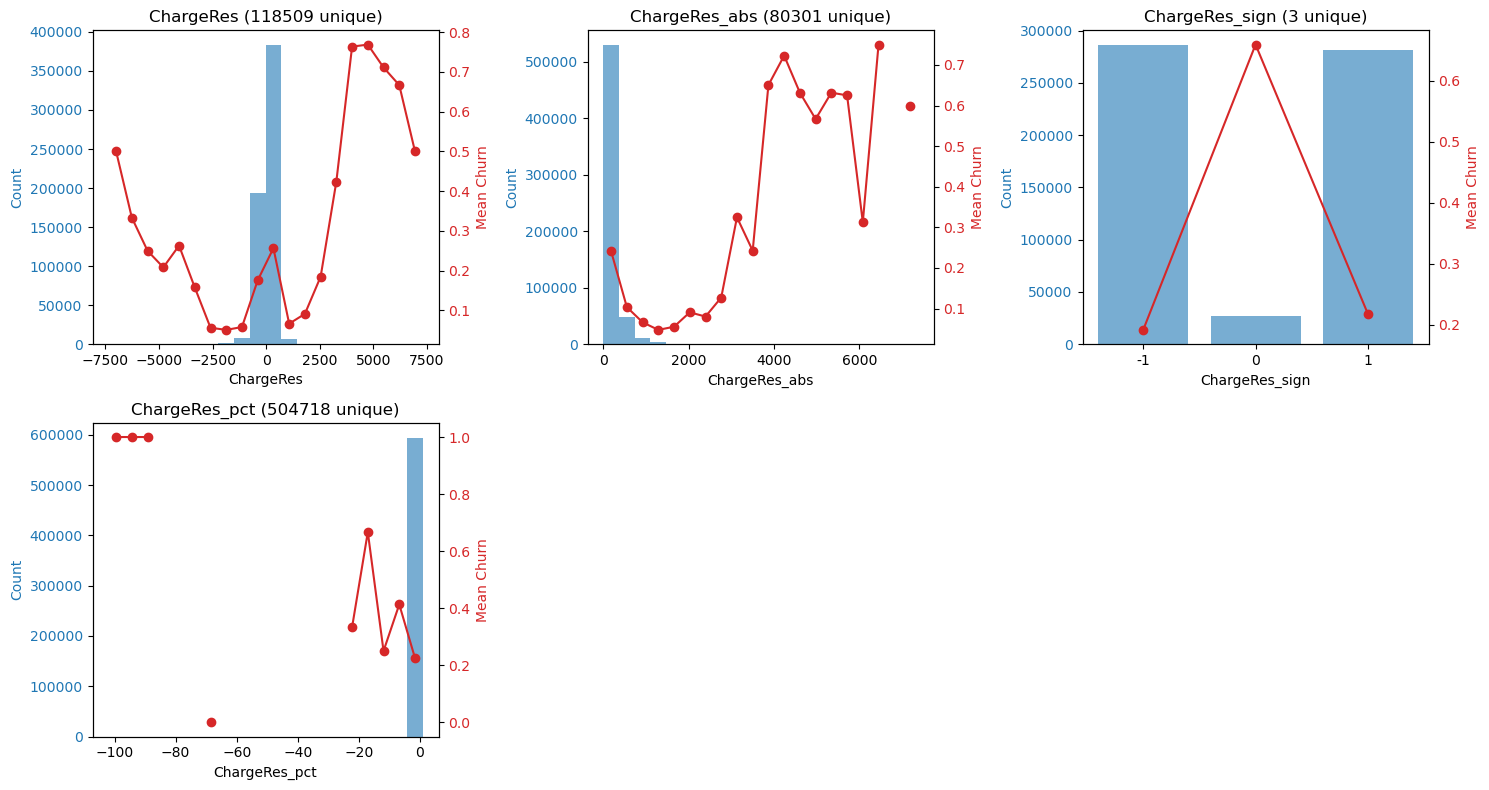

In [110]:
used_feats = ["ChargeRes", "ChargeRes_abs", "ChargeRes_sign", "ChargeRes_pct"]
n_cols = 3
n_rows = (len(used_feats) + n_cols - 1) // n_cols
n_bins = 20

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(used_feats):
    ax1 = axes[i]
    x = train[col].dropna().values
    y = train.loc[train[col].notna(), 'Churn'].values

    unique_vals = np.sort(np.unique(x))
    n_unique = len(unique_vals)

    # Low-cardinality: one bar per unique value
    if n_unique <= 20:
        counts = np.array([(x == v).sum() for v in unique_vals])
        mean_y = np.array([y[x == v].mean() for v in unique_vals])
        xpos = np.arange(n_unique)

        ax1.bar(xpos, counts, alpha=0.6, color='tab:blue')
        ax1.set_xticks(xpos)
        ax1.set_xticklabels(unique_vals.astype(int) if np.all(unique_vals == unique_vals.astype(int)) else unique_vals,
                            rotation=45 if n_unique > 10 else 0, 
                            ha='right' if n_unique > 10 else 'center')

        ax2 = ax1.twinx()
        ax2.plot(xpos, mean_y, marker='o', color='tab:red')

    # High-cardinality: binned histogram
    else:
        bins = np.linspace(x.min(), x.max(), n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        counts, _ = np.histogram(x, bins=bins)
        bin_idx = np.digitize(x, bins) - 1
        mean_y = np.array([y[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                           for j in range(n_bins)])

        ax1.bar(bin_centers, counts, width=(bins[1] - bins[0]), alpha=0.6, color='tab:blue')

        ax2 = ax1.twinx()
        ax2.plot(bin_centers, mean_y, marker='o', color='tab:red')

    ax1.set_xlabel(col)
    ax1.set_ylabel('Count', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylabel('Mean Churn', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_title(f'{col} ({n_unique} unique)')

for i in range(len(used_feats), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()